In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load and preprocess the dataset
df = pd.read_csv("tmdb_movies_dataset.csv")

# Strip whitespace from column names
df.columns = df.columns.str.strip()

print(f"Dataset shape: {df.shape}")
print(f"\nDataset info:")
print(df.info())

Dataset shape: (4000, 6)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie_id      4000 non-null   int64  
 1   title         4000 non-null   object 
 2   release_date  3984 non-null   object 
 3   vote_count    4000 non-null   int64  
 4   popularity    4000 non-null   float64
 5   rating        4000 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 187.6+ KB
None


In [3]:
# Display first 5 rows
print(df.head())

   movie_id                                   title release_date  vote_count  \
0    798645                         The Running Man   11/11/2025         598   
1   1084242                              Zootopia 2   11/26/2025         643   
2   1223601                   Sisu: Road to Revenge   10/21/2025         115   
3    812583  Wake Up Dead Man: A Knives Out Mystery   11/26/2025         697   
4   1387382                          Hunting Season    12/5/2025          33   

   popularity  rating  
0    418.0257   6.872  
1    382.4108   7.635  
2    386.9594   7.700  
3    344.9733   7.334  
4    227.3166   6.985  


In [4]:
# Statistical summary
print(df.describe())

           movie_id    vote_count   popularity       rating
count  4.000000e+03   4000.000000  4000.000000  4000.000000
mean   4.262804e+05   2659.169750    11.102972     6.103547
std    4.532085e+05   4774.681902    17.866908     1.937754
min    5.000000e+00      0.000000     3.508900     0.000000
25%    1.984050e+04     21.000000     6.736750     5.700000
50%    2.789270e+05    371.500000     7.742900     6.577000
75%    7.528028e+05   3156.500000     9.831625     7.233250
max    1.591771e+06  38409.000000   418.025700    10.000000


In [5]:
# Display last 5 rows
print(df.tail())

      movie_id                        title release_date  vote_count  \
3995    281259      The Winds of Kitty Hawk   12/17/1978           0   
3996    130150                    Labor Day   12/27/2013        1268   
3997    225468                Global Effect   12/12/2002          10   
3998    530183  The Warrior Queen of Jhansi   11/15/2019          11   
3999   1370458   La Flûte [cyber] enchantée    3/27/2021           0   

      popularity  rating  
3995      5.6079   0.000  
3996      5.9497   7.026  
3997      6.4018   4.400  
3998      5.2946   6.100  
3999      5.6309   0.000  


In [6]:
# Random sample of 5 rows
print(df.sample(5))

      movie_id                     title release_date  vote_count  popularity  \
1301     16198  My Neighbors the Yamadas    7/17/1999         581      9.0198   
981       5174               Rush Hour 3     8/8/2007        3563     10.0638   
203     263115                     Logan    2/28/2017       19992     23.7297   
2838   1291040            Mrs. Christmas   11/26/2025          17      6.9758   
1218   1302001                     Top 1     7/2/2024           8     10.4292   

      rating  
1301   7.027  
981    6.481  
203    7.819  
2838   6.029  
1218   5.375  


In [7]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
movie_id         0
title            0
release_date    16
vote_count       0
popularity       0
rating           0
dtype: int64

Total missing values: 16


In [8]:
# Data Preprocessing
# Convert release_date to datetime and extract features
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_day'] = df['release_date'].dt.day

# Drop rows with missing values
df = df.dropna()

print(f"Dataset shape after cleaning: {df.shape}")
print(df.info())

Dataset shape after cleaning: (3984, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 3984 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   movie_id       3984 non-null   int64         
 1   title          3984 non-null   object        
 2   release_date   3984 non-null   datetime64[ns]
 3   vote_count     3984 non-null   int64         
 4   popularity     3984 non-null   float64       
 5   rating         3984 non-null   float64       
 6   release_year   3984 non-null   float64       
 7   release_month  3984 non-null   float64       
 8   release_day    3984 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2), object(1)
memory usage: 311.2+ KB
None


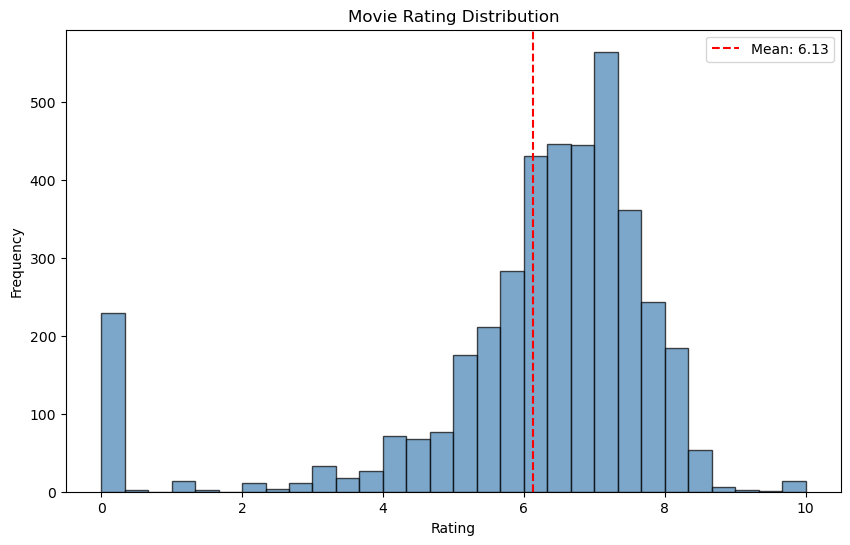

In [9]:
# Visualize rating distribution
plt.figure(figsize=(10, 6))
plt.hist(df['rating'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Movie Rating Distribution")
plt.axvline(df['rating'].mean(), color='red', linestyle='--', label=f'Mean: {df["rating"].mean():.2f}')
plt.legend()
plt.savefig("rating_distribution.png")
plt.show()

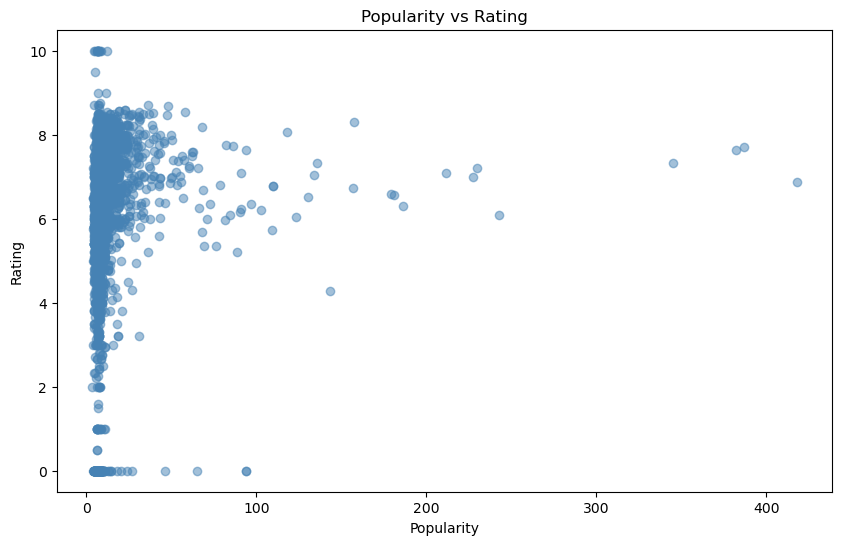

In [10]:
# Popularity vs Rating scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['popularity'], df['rating'], alpha=0.5, c='steelblue')
plt.xlabel("Popularity")
plt.ylabel("Rating")
plt.title("Popularity vs Rating")
plt.savefig("popularity_vs_rating.png")
plt.show()

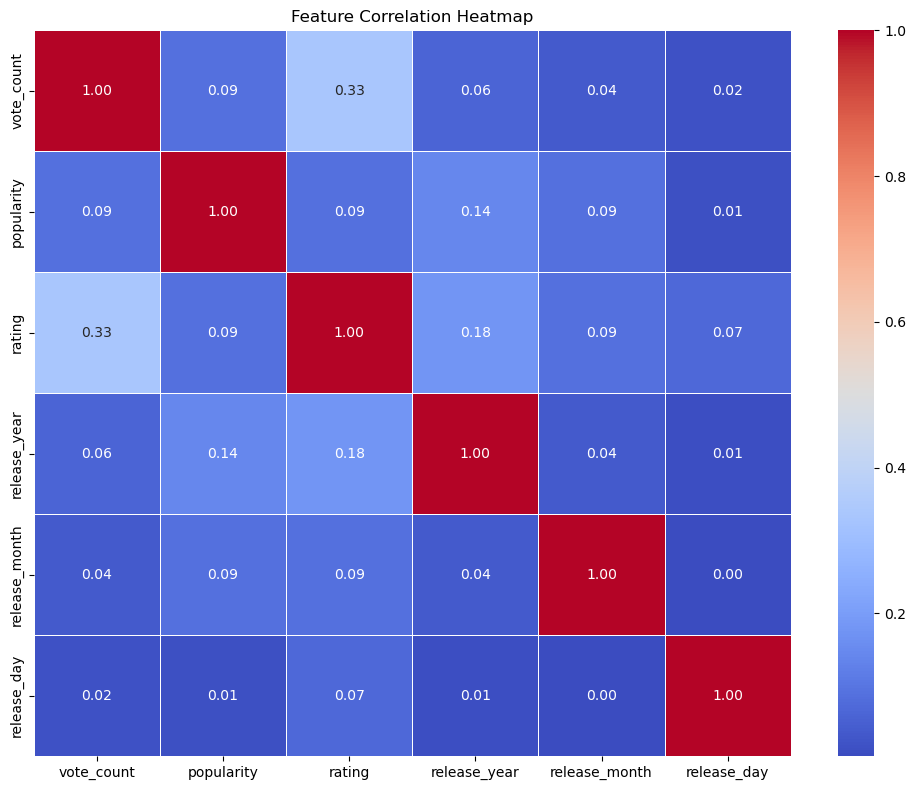

In [11]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = ['vote_count', 'popularity', 'rating', 'release_year', 'release_month', 'release_day']
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

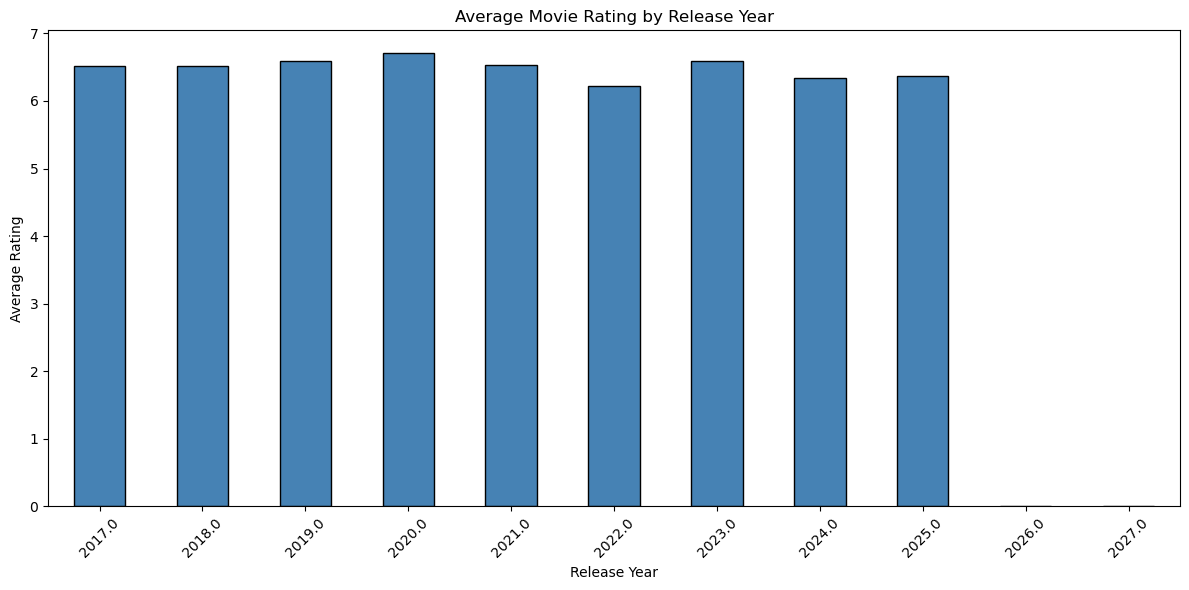

In [12]:
# Average rating by release year (last 10 years)
recent_years = df[df['release_year'] >= df['release_year'].max() - 10]
yearly_rating = recent_years.groupby('release_year')['rating'].mean()

plt.figure(figsize=(12, 6))
yearly_rating.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel("Release Year")
plt.ylabel("Average Rating")
plt.title("Average Movie Rating by Release Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("rating_by_year.png")
plt.show()

In [13]:
# Split the dataset into features (X) and target (y)
# We'll predict the rating based on vote_count, popularity, and release date features
feature_cols = ['vote_count', 'popularity', 'release_year', 'release_month', 'release_day']
X = df[feature_cols]
y = df['rating']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (3984, 5)
Target shape: (3984,)

Feature columns: ['vote_count', 'popularity', 'release_year', 'release_month', 'release_day']


In [14]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing set: X_test = {X_test.shape}, y_test = {y_test.shape}")

Training set: X_train = (3187, 5), y_train = (3187,)
Testing set: X_test = (797, 5), y_test = (797,)


In [15]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling completed!")

Feature scaling completed!


In [16]:
# Initialize multiple regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print("Models initialized:")
for name in models.keys():
    print(f"  - {name}")

Models initialized:
  - Linear Regression
  - Ridge Regression
  - Lasso Regression
  - Random Forest
  - Gradient Boosting


In [17]:
# Train all models and evaluate
results = []

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2 Score': r2
    })
    
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")


Model: Linear Regression
MSE: 2.8391
RMSE: 1.6849
MAE: 1.1377
R2 Score: 0.1247

Model: Ridge Regression
MSE: 2.8390
RMSE: 1.6849
MAE: 1.1376
R2 Score: 0.1247

Model: Lasso Regression
MSE: 2.8416
RMSE: 1.6857
MAE: 1.1217
R2 Score: 0.1240

Model: Random Forest
MSE: 0.5921
RMSE: 0.7695
MAE: 0.5152
R2 Score: 0.8174

Model: Gradient Boosting
MSE: 0.8059
RMSE: 0.8977
MAE: 0.6524
R2 Score: 0.7516


In [18]:
# Model Comparison Table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2 Score', ascending=False)
print("\n" + "="*70)
print("MODEL COMPARISON (Sorted by R2 Score)")
print("="*70)
print(results_df.to_string(index=False))


MODEL COMPARISON (Sorted by R2 Score)
            Model      MSE     RMSE      MAE  R2 Score
    Random Forest 0.592142 0.769507 0.515176  0.817446
Gradient Boosting 0.805862 0.897698 0.652351  0.751557
 Ridge Regression 2.839018 1.684939 1.137641  0.124745
Linear Regression 2.839053 1.684949 1.137671  0.124734
 Lasso Regression 2.841568 1.685695 1.121749  0.123959


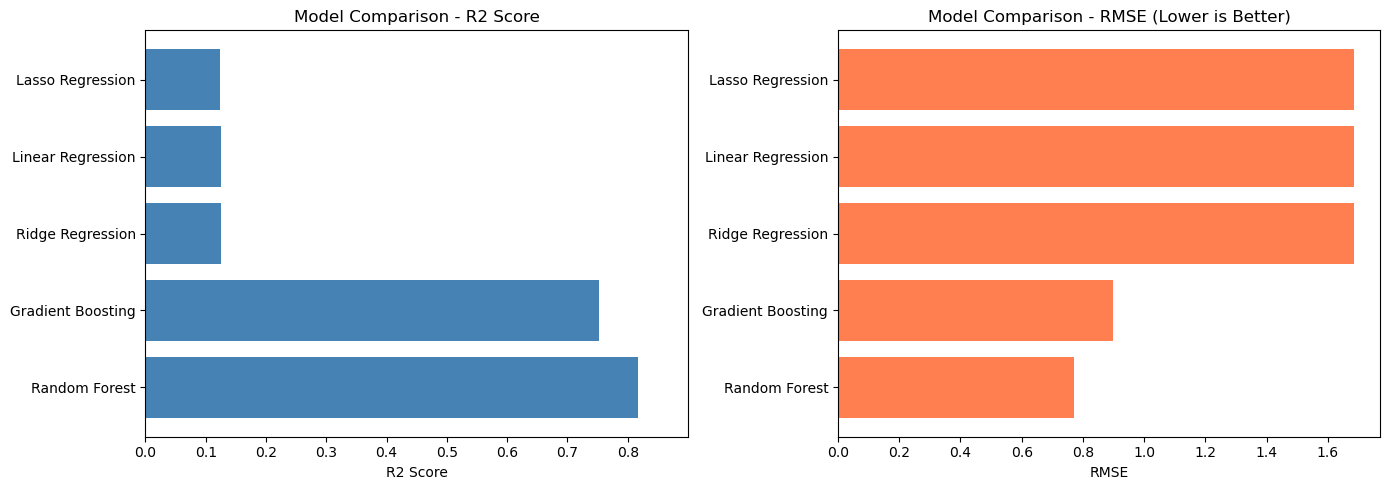

In [19]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 Score comparison
axes[0].barh(results_df['Model'], results_df['R2 Score'], color='steelblue')
axes[0].set_xlabel('R2 Score')
axes[0].set_title('Model Comparison - R2 Score')
axes[0].set_xlim(0, max(results_df['R2 Score']) * 1.1)

# RMSE comparison
axes[1].barh(results_df['Model'], results_df['RMSE'], color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison - RMSE (Lower is Better)')

plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

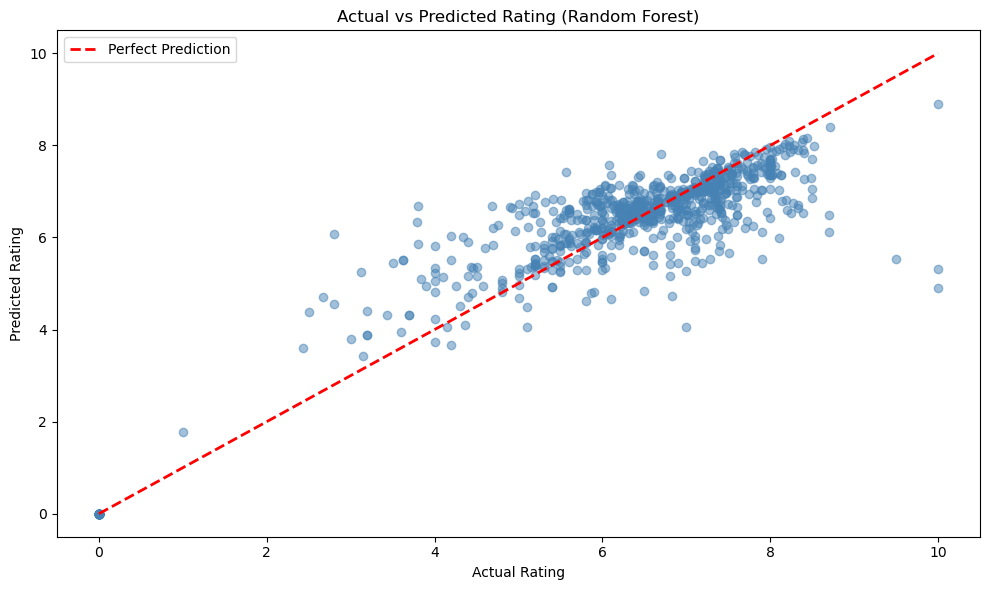

In [20]:
# Actual vs Predicted for best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, c='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title(f'Actual vs Predicted Rating ({best_model_name})')
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()

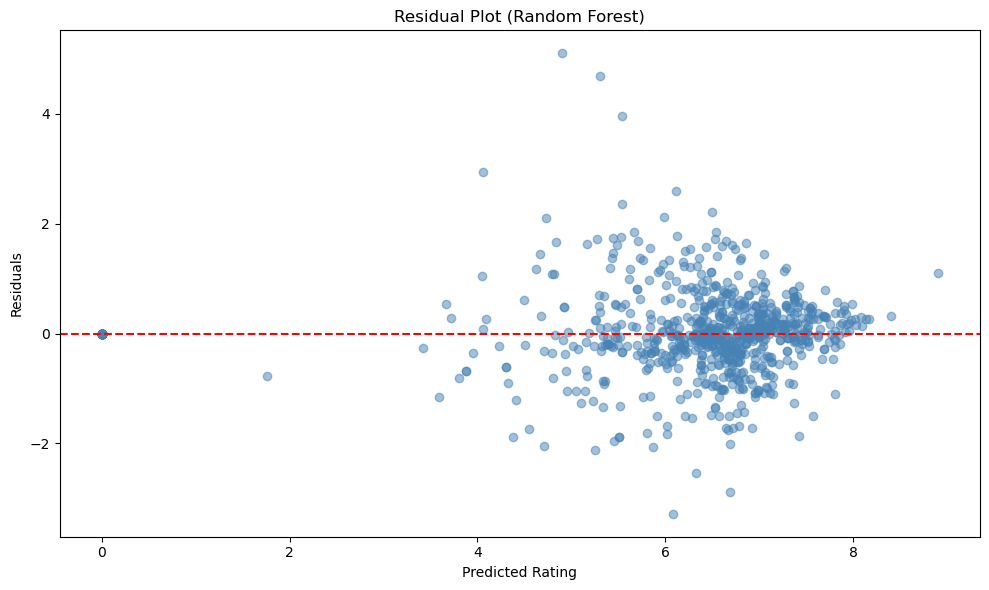

In [21]:
# Residual plot for best model
residuals = y_test - y_pred_best

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_best, residuals, alpha=0.5, c='steelblue')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Rating')
plt.ylabel('Residuals')
plt.title(f'Residual Plot ({best_model_name})')
plt.tight_layout()
plt.savefig("residual_plot.png")
plt.show()

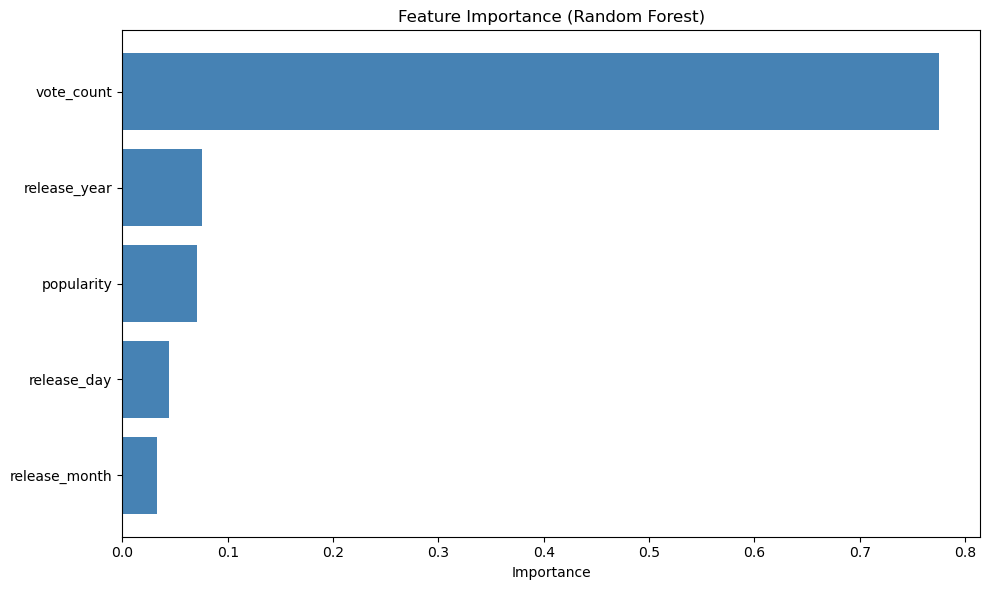

In [22]:
# Feature importance for tree-based models
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
    plt.xlabel('Importance')
    plt.title(f'Feature Importance ({best_model_name})')
    plt.tight_layout()
    plt.savefig("feature_importance.png")
    plt.show()
else:
    print(f"{best_model_name} does not have feature_importances_ attribute.")

In [23]:
# Select the best model and save it
print(f"Best performing model: {best_model_name}")
print(f"R2 Score: {results_df.iloc[0]['R2 Score']:.4f}")
print(f"RMSE: {results_df.iloc[0]['RMSE']:.4f}")

# Save the best model
import joblib
joblib.dump(best_model, "movie_rating_model.joblib")
joblib.dump(scaler, "scaler.joblib")
print("\nModel saved as 'movie_rating_model.joblib'")
print("Scaler saved as 'scaler.joblib'")

Best performing model: Random Forest
R2 Score: 0.8174
RMSE: 0.7695

Model saved as 'movie_rating_model.joblib'
Scaler saved as 'scaler.joblib'


In [24]:
# Make prediction on a sample from test set
sample_idx = X_test.sample(1).index[0]
sample = X_test.loc[[sample_idx]]
sample_scaled = scaler.transform(sample)
prediction = best_model.predict(sample_scaled)[0]
actual = y_test.loc[sample_idx]

print("Sample Movie Data:")
print(sample)
print(f"\nActual Rating: {actual:.2f}")
print(f"Predicted Rating: {prediction:.2f}")
print(f"Difference: {abs(actual - prediction):.2f}")

Sample Movie Data:
     vote_count  popularity  release_year  release_month  release_day
572        8570     12.9085        2005.0            4.0          1.0

Actual Rating: 7.46
Predicted Rating: 7.29
Difference: 0.17
